# The Monte Carlo Method

In this notebook one can find the recipe for Pi. Althoug less tasty then the pastry, it is equaly important!
Let's break it down to a few simple stages:

1. We get ourself a thousand people :)
2. We give each one x, y coordinates
3. We set a simple rule for them to reise a green or red flag
4. We find an interesting relation between the two

Let us start with a "random" rule:

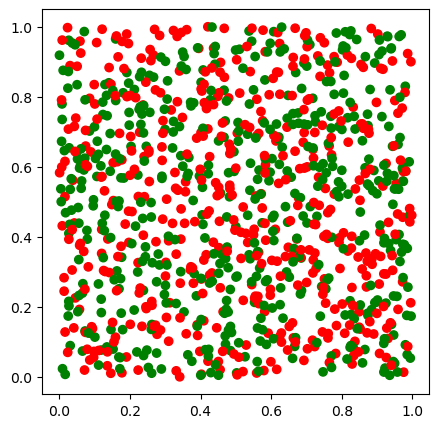

In [1]:
import ipywidgets as widgets
import random
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 5))

number_of_people = 1000
xcors = []
ycors = []
colors = []

for i in range(number_of_people):
    xcors.append(random.random())
    ycors.append(random.random())
    colors.append(random.choice(["green", "red"]))
    
plt.scatter(xcors, ycors, c=colors)

Fantastic! Chaos!

If python's random function is in fact random, the ratio of red flags to the to the goroup size should be around 0.5.
let us check:

In [2]:
print(colors.count("red")/number_of_people)

0.493


While not very interesting by itself, it's good to see that we can count on python to do it's job.


Now let's make a rule to devide the people by a function:<br>People who's y coordinat is below the function will wave a red flag while people above will wave green.

Beneth the graph you can find two interactable fetures:<br>
The first is the size of the group (the amount of people participating).<br>
The second one is our deviding function (shows `f(x) = x` for now).

Try changing the function to your desire. You can try:

* a number (preferably between 0 and 1)
* `f(x) = 5*x`
* or go crazy with `f(x) = (2*x-1)**3+0.5`

Every function that includes `x` should work and bring diferent resaults.

A few simple rules to know about python syntax:

`+` $\rightarrow$ add

`-` $\rightarrow$ subtract

`*` $\rightarrow$ multiply

`/` $\rightarrow$ devide

`**` $\rightarrow$ power (`3**2 = 9`)

In [10]:
import ipywidgets as widgets
import random
import matplotlib.pyplot as plt

red_ratio = widgets.Label()
almos_pi = widgets.Label()

def plot_function_and_people(group_size, line_function):
    xcors = []
    ycors = []
    colors = []

    def function(x):
        d = {"x": x}
        exec("out = " + line_function, d)
        return d["out"]
        
    for i in range(group_size):
        x = random.random()
        y = random.random()
        if y < function(x):
            colors.append("red")
        else:
            colors.append("green")
        xcors.append(x)
        ycors.append(y)
    
    x_func = [i/100 for i in range(1, 101)]
    y_func = [function(x) for x in x_func]
    red_ratio.value = r"$\frac{Red Flags}{All People}$ = " + str(colors.count("red")/group_size)
    almos_pi.value = r"$4\times\frac{Red Flags}{All People}$ = " + str(4*colors.count("red")/group_size)

    plt.figure(figsize=(5, 5))
    plt.scatter(xcors, ycors, c=colors)
    plt.plot(x_func, y_func, linewidth=5, c="black")
    plt.xlim(0, 1)
    plt.ylim(0, 1)

widgets.interact(plot_function_and_people, group_size=widgets.IntSlider(1000, min=10, max=10000, description="Group Size"), line_function=widgets.Text("x", description="f(x) = "))

display(red_ratio, almos_pi)

interactive(children=(IntSlider(value=1000, description='Group Size', max=10000, min=10), Text(value='x', desc…

Label(value='$\\frac{Red Flags}{All People}$ = 0.477')

Label(value='$4\\times\\frac{Red Flags}{All People}$ = 1.908')

The two numbers below the graph shows us the ratio of red flags to the total amount of people and four times that number.<br>We will talk about this number in a litle bit, but first of all try changing the function to see how these numbers change.

After you played with the function a little, try enlarging the number of peaople.<br>You can see that as the amount grows there is less and less "free" space on the graph and most of it is colored in either red or green. It is almost as we fill the area of our square with color.

We can infer that the ratio of the "red" people to the total amount of people should be close to the ratio of the red "area" (the are under the function)<br>to the area of our 1X1 square: $\frac{Red Flags}{All People} \approx \frac{Area Under Function}{Area Of Square}$. In our case the area of the square is $1$ so we get this formula:

$\frac{Red Flags}{All People} \approx Area Under Function$

You can now go back and change the function to `f(x) = x` and see how this ratio get closer to $0.5$ as you add more and more people.

### The full <span style="color:Red">Pi</span>cture

You must ask yourself "how does this relates to $\pi$?..."

Well, I want you to go back and set the function to this expression `(1-x**2)**0.5`.<br>This is simply the function that will show us a circle with radius 1, in this case a quarter of a circle.<br>In non-python text it will look like this: $f(x) = \sqrt{1-x^2}$

The area under the graph should be the are of this quarter circle: $\frac{\pi r^2}{4}$.<br>Putting this in our eqation will give us: $\frac{Red Flags}{All People} \approx \frac{\pi r^2}{4}$.<br>Substituding $r$ for 1 and multiplying everything by 4 will give us: $4\times\frac{Red Flags}{All People} \approx \pi$


Try setting the group size to the maximum and look at the second ratio under the graph.<br>It will, of course, never be exactly $\pi$ but it should be close enough ($\pi \approx 3.1415926...$)

Not only can the Monte Carlo method help us find an aproximation of $\pi$ in an empiric way, it can also help compute dificalt integrals of complex functions.<br>I think it is very impresive that in total randomnes (the positions of the people in this case), using one rule can provide order and information.